# Step 1: Data Exploration (BCI Competition IV-2a)

**Project:** EEG-based motor-imagery wheelchair control with cross-subject generalization and uncertainty-aware command rejection.

**Goal of this notebook:** load the dataset, check its structure, and understand what one trial looks like before any preprocessing or modelling.

| Property | Expected value |
|---|---|
| Subjects | 9 (A01–A09) |
| Sessions per subject | 2: `T` (training) and `E` (evaluation) |
| Channels | 22 EEG + 3 EOG |
| Sampling rate | 250 Hz |
| Classes | left hand, right hand, feet, tongue |
| Trials per session | 288 (72 per class) |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data import (CLASS_NAMES, CUE_CODES, EEG_CHANNELS, EOG_CHANNELS, EVENT_CODES, SUBJECTS,
                  cue_events, load_raw, trial_rejected_mask)

mne.set_log_level("ERROR")
FIG_DIR = Path.cwd().parent / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Load one recording (subject A01, training session)

In [2]:
raw = load_raw("A01", "T")

n_eeg = len(mne.pick_types(raw.info, eeg=True))
n_eog = len(mne.pick_types(raw.info, eog=True))
print(f"File            : A01T.gdf")
print(f"Channels        : {len(raw.ch_names)}  ({n_eeg} EEG + {n_eog} EOG)")
print(f"Sampling rate   : {raw.info['sfreq']:.0f} Hz")
print(f"Duration        : {raw.times[-1] / 60:.1f} min  ({raw.n_times:,} samples per channel)")
print(f"Hardware filter : {raw.info['highpass']}–{raw.info['lowpass']} Hz (plus 50 Hz notch at recording)")
print(f"\nEEG channels    : {EEG_CHANNELS}")
print(f"EOG channels    : {EOG_CHANNELS}")

File            : A01T.gdf
Channels        : 25  (22 EEG + 3 EOG)
Sampling rate   : 250 Hz
Duration        : 44.8 min  (672,528 samples per channel)
Hardware filter : 0.5–100.0 Hz (plus 50 Hz notch at recording)

EEG channels    : ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
EOG channels    : ['EOG-left', 'EOG-central', 'EOG-right']


### Electrode layout
The 22 EEG electrodes sit over the **sensorimotor cortex**. That is where motor imagery changes the mu (8–13 Hz) and beta (13–30 Hz) rhythms. C3 sits over the left hemisphere (controls the right hand) and C4 over the right (controls the left hand).

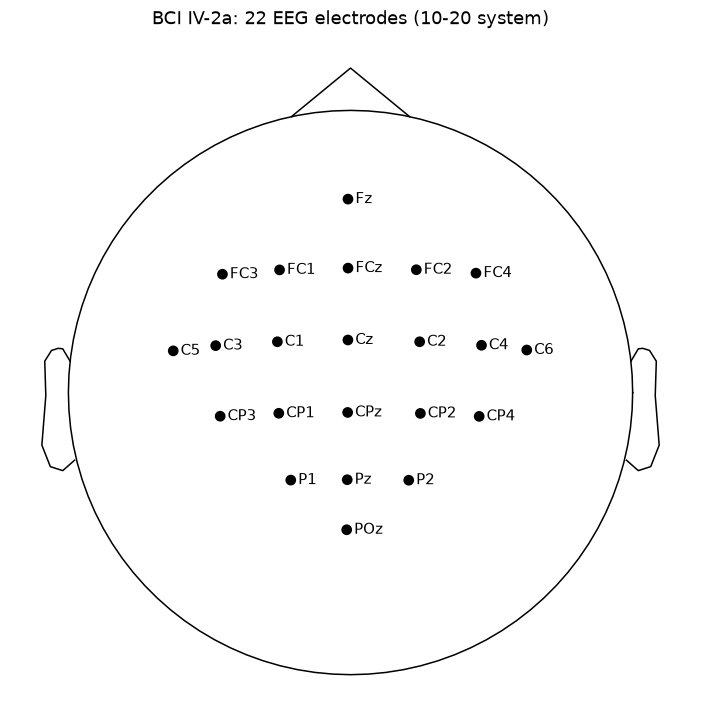

In [3]:
fig = raw.copy().pick("eeg").plot_sensors(show_names=True, show=False)
fig.suptitle("BCI IV-2a: 22 EEG electrodes (10-20 system)")
fig.savefig(FIG_DIR / "01_electrode_layout.png", bbox_inches="tight")
plt.show()

## 2. Events stored in the file
Each recording carries event markers. These tell us where every trial starts and which class was cued.

In [4]:
codes, counts = np.unique(raw.annotations.description, return_counts=True)
events_table = pd.DataFrame({"code": codes, "meaning": [EVENT_CODES.get(c, "?") for c in codes], "count": counts})
events_table.sort_values("code", key=lambda s: s.astype(int)).reset_index(drop=True)

,code,meaning,count
0,276,"Idle, eyes open",1
1,277,"Idle, eyes closed",1
2,768,Start of a trial,288
3,769,Cue: left hand (class 1),72
4,770,Cue: right hand (class 2),72
5,771,Cue: feet (class 3),72
6,772,Cue: tongue (class 4),72
7,1023,Rejected trial (expert-marked artifact),15
8,1072,Eye movements (EOG calibration),1
9,32766,Start of a new run,9


## 3. Timeline of one trial
From the dataset description:
- **t = 0 s**: fixation cross and a short beep
- **t = 2 s**: an arrow cue (left / right / down / up) shows the class for 1.25 s
- **t = 2–6 s**: the subject performs the motor imagery
- **t = 6 s**: a short break, then the next trial

For modelling we will cut the **4 s after the cue (2–6 s)**, where the imagery happens (shaded band).

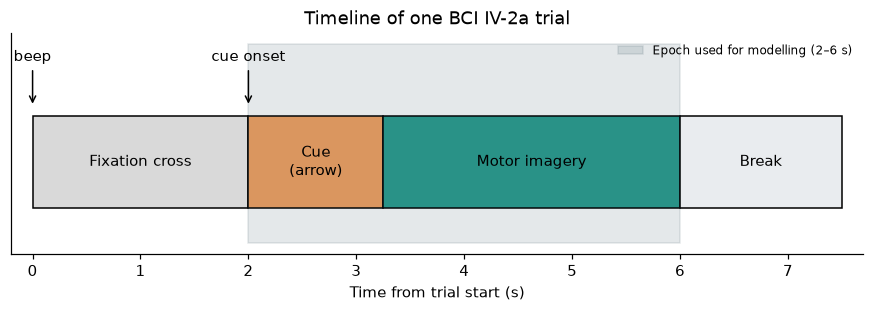

In [5]:
fig, ax = plt.subplots(figsize=(10, 2.6))
segments = [(0, 2, "Fixation cross", "#d9d9d9"), (2, 3.25, "Cue\n(arrow)", "#f4a261"),
            (3.25, 6, "Motor imagery", "#2a9d8f"), (6, 7.5, "Break", "#e9ecef")]
for start, end, label, color in segments:
    ax.barh(0, end - start, left=start, height=0.5, color=color, edgecolor="black")
    ax.text((start + end) / 2, 0, label, ha="center", va="center", fontsize=10)
ax.axvspan(2, 6, ymin=0.05, ymax=0.95, color="#264653", alpha=0.12, label="Epoch used for modelling (2–6 s)")
for t, lab in [(0, "beep"), (2, "cue onset")]:
    ax.annotate(lab, (t, 0.3), (t, 0.55), ha="center", arrowprops=dict(arrowstyle="->"))
ax.set_xlim(-0.2, 7.7); ax.set_ylim(-0.5, 0.7); ax.set_yticks([])
ax.set_xlabel("Time from trial start (s)"); ax.set_title("Timeline of one BCI IV-2a trial")
ax.legend(loc="upper right", fontsize=8, frameon=False)
fig.savefig(FIG_DIR / "01_trial_timeline.png", bbox_inches="tight")
plt.show()

## 4. Raw EEG around one trial
The first left-hand trial of A01T, showing motor-cortex channels plus one EOG channel. Nothing is filtered yet, so this is exactly what the model would see without preprocessing.

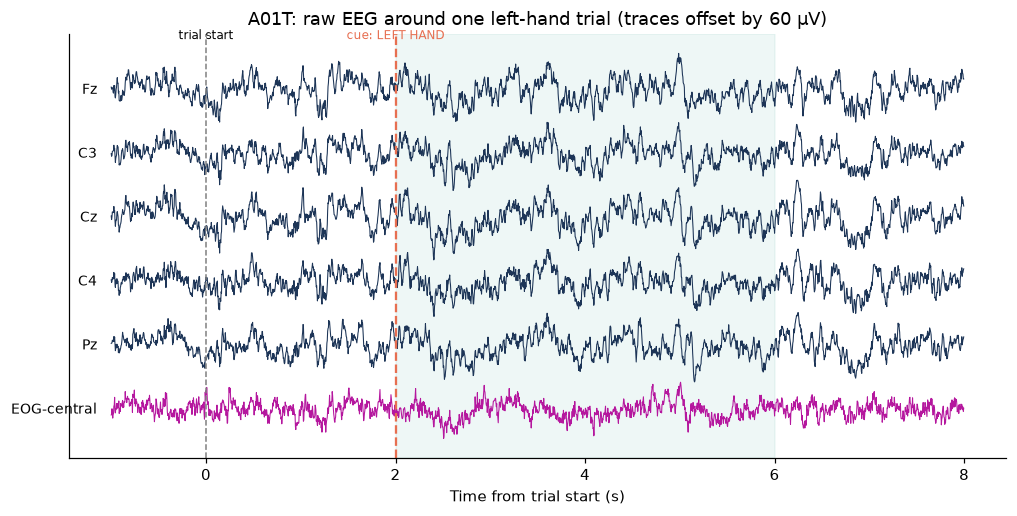

In [6]:
events, event_id = cue_events(raw)
sf = raw.info["sfreq"]
cue_sample = events[events[:, 2] == event_id["left_hand"]][0, 0]
start, stop = int(cue_sample - 3 * sf), int(cue_sample + 6 * sf)   # trial start - 1 s ... cue + 6 s

show = ["Fz", "C3", "Cz", "C4", "Pz", "EOG-central"]
data = raw.get_data(picks=show, start=start, stop=stop) * 1e6       # volts -> microvolts
t = (np.arange(start, stop) - cue_sample) / sf + 2                  # time relative to trial start

fig, ax = plt.subplots(figsize=(11, 5))
offset = 60
for i, (ch, sig) in enumerate(zip(show, data)):
    sig = sig - sig.mean()
    ax.plot(t, sig - i * offset, lw=0.7, color="#b5179e" if ch.startswith("EOG") else "#1d3557")
    ax.text(t[0] - 0.15, -i * offset, ch, ha="right", va="center", fontsize=9)
ax.axvline(0, color="grey", ls="--", lw=1); ax.text(0, offset * 0.8, "trial start", ha="center", fontsize=8)
ax.axvline(2, color="#e76f51", ls="--", lw=1.5); ax.text(2, offset * 0.8, "cue: LEFT HAND", ha="center", fontsize=8, color="#e76f51")
ax.axvspan(2, 6, color="#2a9d8f", alpha=0.08)
ax.set_yticks([]); ax.set_xlabel("Time from trial start (s)")
ax.set_title(f"A01T: raw EEG around one left-hand trial (traces offset by {offset} µV)")
fig.savefig(FIG_DIR / "01_raw_eeg_one_trial.png", bbox_inches="tight")
plt.show()

## 5. Class balance (A01T)

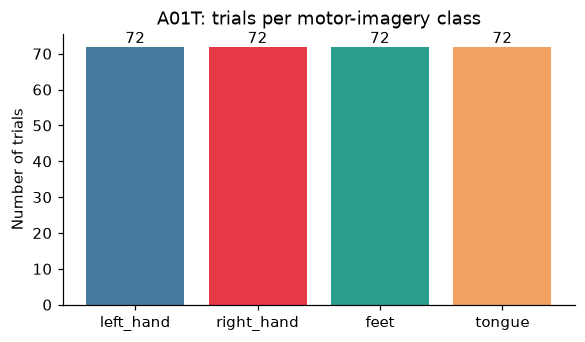

Perfectly balanced, so chance-level accuracy for 4 classes is 25%.


In [7]:
labels = events[:, 2]
counts = np.bincount(labels, minlength=4)
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.bar(CLASS_NAMES, counts, color=["#457b9d", "#e63946", "#2a9d8f", "#f4a261"])
ax.bar_label(bars)
ax.set_ylabel("Number of trials"); ax.set_title("A01T: trials per motor-imagery class")
fig.savefig(FIG_DIR / "01_class_balance_A01T.png", bbox_inches="tight")
plt.show()
print("Perfectly balanced, so chance-level accuracy for 4 classes is 25%.")

## 6. All 9 subjects: dataset summary
Summary of both sessions for every subject:
- **rejected trials**: trials that the dataset's experts marked as containing artifacts (event 1023)
- **clipped trials**: trials whose motor-imagery window (2–6 s) contains samples stuck at the amplifier limit

In [8]:
rows = []
for subj in SUBJECTS:
    for sess in ["T", "E"]:
        r = load_raw(subj, sess)
        desc = r.annotations.description
        starts = r.annotations.onset[desc == "768"]
        eeg = r.get_data(picks="eeg")
        clipped = np.abs(eeg).max(axis=0) >= 1500e-6   # stored at the int16 limit (~1600 µV); real EEG is far smaller
        sfr = r.info["sfreq"]
        clipped_trials = sum(clipped[int((s + 2) * sfr): int((s + 6) * sfr)].any() for s in starts)
        row = {"subject": subj, "session": sess, "minutes": round(r.times[-1] / 60, 1),
               "trials": len(starts), "labels_in_file": "yes" if sess == "T" else "no (cue 783)"}
        for code_, name in CUE_CODES.items():
            row[name] = int((desc == code_).sum())
        row["rejected_trials"] = int(trial_rejected_mask(r).sum())
        row["clipped_trials"] = int(clipped_trials)
        rows.append(row)

summary = pd.DataFrame(rows)
summary.to_csv(Path.cwd().parent / "results" / "dataset_summary.csv", index=False)
summary

,subject,session,minutes,trials,labels_in_file,left_hand,right_hand,feet,tongue,rejected_trials,clipped_trials
0,A01,T,44.8,288,yes,72,72,72,72,15,0
1,A01,E,45.8,288,no (cue 783),0,0,0,0,7,0
2,A02,T,45.1,288,yes,72,72,72,72,18,0
3,A02,E,44.2,288,no (cue 783),0,0,0,0,5,0
4,A03,T,44.0,288,yes,72,72,72,72,18,0
5,A03,E,43.3,288,no (cue 783),0,0,0,0,15,0
6,A04,T,40.1,288,yes,72,72,72,72,26,0
7,A04,E,44.0,288,no (cue 783),0,0,0,0,60,0
8,A05,T,45.7,288,yes,72,72,72,72,26,0
9,A05,E,45.3,288,no (cue 783),0,0,0,0,12,0


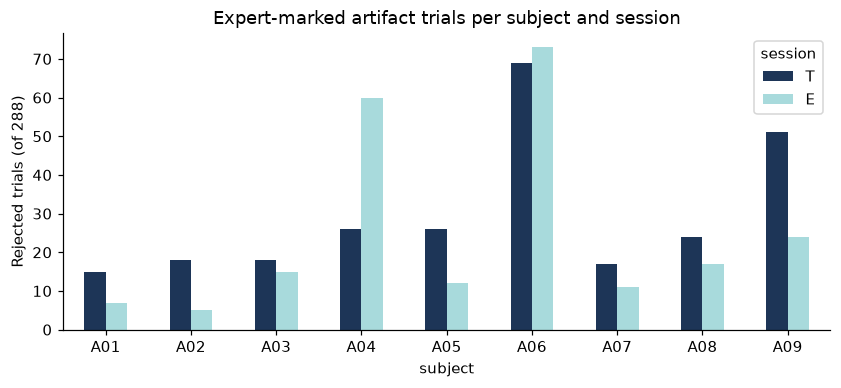

Training sessions: 2592 trials in total, {'left_hand': 648, 'right_hand': 648, 'feet': 648, 'tongue': 648}
Rejected trials (T): 264 of 2592 (10.2%), range 15–69 per subject


In [9]:
pivot = summary.pivot(index="subject", columns="session", values="rejected_trials")[["T", "E"]]
ax = pivot.plot.bar(figsize=(9, 3.5), color=["#1d3557", "#a8dadc"], rot=0)
ax.set_ylabel("Rejected trials (of 288)"); ax.set_title("Expert-marked artifact trials per subject and session")
ax.figure.savefig(FIG_DIR / "01_rejected_trials.png", bbox_inches="tight")
plt.show()

T = summary[summary.session == "T"]
print(f"Training sessions: {T.trials.sum()} trials in total, {T[CLASS_NAMES].sum().to_dict()}")
print(f"Rejected trials (T): {T.rejected_trials.sum()} of {T.trials.sum()} "
      f"({100 * T.rejected_trials.sum() / T.trials.sum():.1f}%), range {T.rejected_trials.min()}–{T.rejected_trials.max()} per subject")

## 7. Key observations

1. **The structure matches the published description.** Every file has 25 channels (22 EEG + 3 EOG) at 250 Hz and 288 trials. Each training session has exactly 72 trials per class, so chance level is **25%**.
2. **Only the training (`T`) sessions carry class labels.** In the evaluation (`E`) files every cue is code 783 ("unknown"), and the true labels ship separately as `.mat` files that are not in our dataset folder yet. **For now we use the 9 `T` sessions: 2,592 labelled trials.**
3. **Expert-marked artifact trials vary a lot between subjects.** In the `T` sessions: 264 of 2,592 (10.2%), from 15 (A01) up to 69 (A06). This is a first sign of the **between-subject variability** our project is about. For the baseline we keep all trials, following Nzakuna et al. (2025).
4. **No motor-imagery window (2–6 s) contains clipped samples.** Samples stuck at the amplifier limit only occur outside trials, so they do not affect our epochs.
5. The EOG channels record eye activity, not brain activity, so they will be **removed** in preprocessing (Step 2).
6. Motor-imagery effects are **not visible by eye** in raw EEG. They appear as power changes in the mu/beta bands, which is why we band-pass filter to 8–30 Hz next.

**Next: Step 2, preprocessing** (remove EOG, then 8–30 Hz band-pass, then 4 s epochs after each cue).